#Importing Data from Kaggle

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("nirmalsankalana/fashion-product-text-images-dataset")

In [4]:
path

'/kaggle/input/datasets/nirmalsankalana/fashion-product-text-images-dataset'

In [5]:
import os
import pandas as pd
import glob

csv_file = glob.glob(f"{path}/**/*.csv", recursive=True)
# print(csv_file[0])
df = pd.read_csv(csv_file[0])
df.head(5)

,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


In [6]:
from torch import nn
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import transforms
import matplotlib.pyplot as plt
import numpy as np

###Reading the imported Dataset from Kaggle

In [7]:
# class ClothingDataset(Dataset):
#   def __init__(self, dataframe, img_dir, transform=None):
#     super().__init__()
#     self.data = []
#     self.transform = transform
#     self.img_dir = img_dir

#     for _, row in dataframe.iterrows():
#       img_name = str(row['image'])
#       label = row['category_encoded']
#       img_file_path = os.path.join(self.img_dir, img_name)
#       image = Image.open(img_file_path).convert('RGB')
#       self.data.append((image, label))

#   def __len__(self):
#     return len(self.data)

#   def __getitem__(self, index):
#     image, label = self.data[index]
#     if self.transform:
#       image = self.transform(image)
#     return image, label


In [8]:
class ClothingDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        super().__init__()
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        img_name = str(row['image'])
        label = row['category_encoded']

        img_file_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_file_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
df['category_encoded'], unique_classes = pd.factorize(df['category'])

In [10]:
df.head(5)

,image,description,display name,category,category_encoded
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes,0
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts,1
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags,2
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches,3
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes,4


In [11]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# image_folder_path = os.path.join(path, 'data')
# dataset = ClothingDataset(df, image_folder_path, transform)

In [12]:
image_folder_path = os.path.join(path, 'data')

#Setting-up device Agonistic Code

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

###Data Analysis Part

In [14]:
class_names = df['category'].unique()
print(f"The dataset has {len(class_names)} unique categories")

The dataset has 142 unique categories


In [15]:
df[df['category'].isna() == True].count()

image               0
description         0
display name        0
category            0
category_encoded    0
dtype: int64

In [16]:
df[df['image'].isna() == True].count()

image               0
description         0
display name        0
category            0
category_encoded    0
dtype: int64

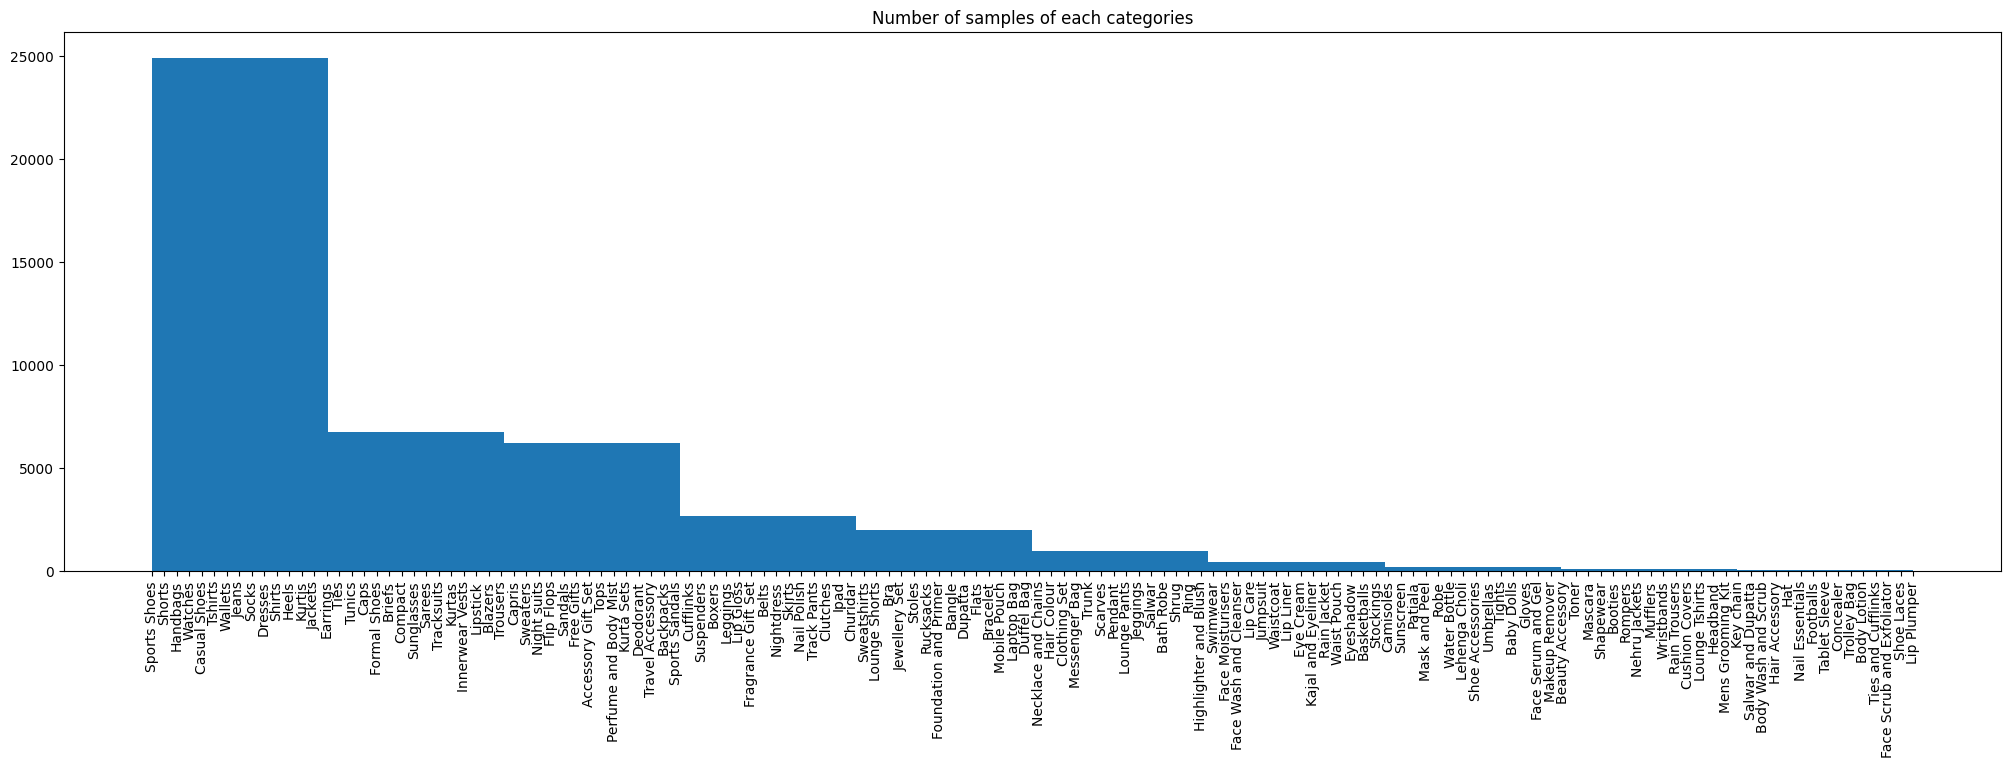

In [17]:
plt.figure(figsize=(25, 7))
plt.hist(df['category'])
plt.xticks(rotation=90)
plt.title('Number of samples of each categories')
plt.show()

In [18]:
df.head(5)

,image,description,display name,category,category_encoded
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes,0
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts,1
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags,2
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches,3
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes,4


In [19]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary

#Pre-Trained Model Selection

In [20]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

###Data Transformation

In [45]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


print(f"{len(train_df)} training set.")
print(f"{len(test_df)} testing set.")

train_cloth_dataset = ClothingDataset(train_df.iloc[:15000], img_dir=image_folder_path, transform=train_transform)
test_cloth_dataset = ClothingDataset(test_df, img_dir=image_folder_path, transform=test_transform)

print(f"{len(train_cloth_dataset)} training set.")
print(f"{len(test_cloth_dataset)} testing set.")

train_data_loader = DataLoader(train_cloth_dataset, batch_size=64, shuffle=True, pin_memory=False)
test_data_loader = DataLoader(test_cloth_dataset, batch_size=64, shuffle=False,pin_memory=False)

35552 training set.
8889 testing set.
15000 training set.
8889 testing set.


In [22]:
train_data, train_label = next(iter(train_data_loader))
test_data, test_label = next(iter(test_data_loader))

In [23]:
train_data[0]

tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         ...,
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],

        [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         ...,
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],

        [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
         [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
         [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.

#Plotting Random Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.64].
Clipping input data t

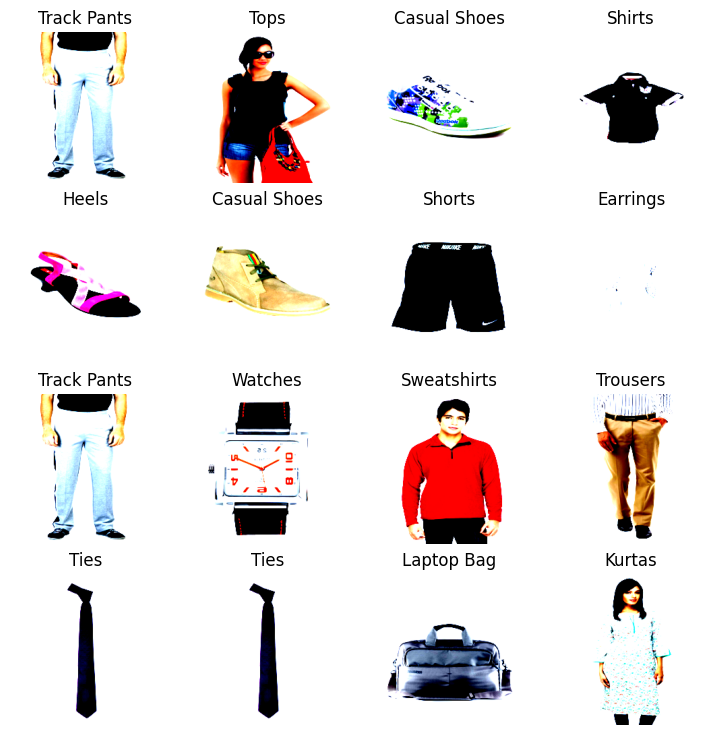

In [24]:
#Plotting more images in random
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_index = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_index], train_label[random_index]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.permute(1,2,0))
  plt.title(class_names[label])
  plt.axis(False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Text(0.5, 1.0, 'Shirts')

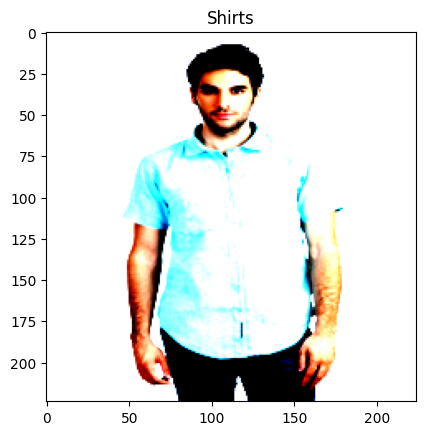

In [25]:
plt.imshow(train_data[5].permute(1,2,0))
plt.title(class_names[train_label[5]])

###Setting up weights for the model

In [81]:
# weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=None)

In [82]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

###Turn-Off/Freeze the parameters

In [83]:
for param in model.parameters():
  param.requires_grad = False

for param in model.classifier[2].parameters():
    param.requires_grad = True

###Create Loss function and optimizer

In [84]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [85]:
model.classifier

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)

In [86]:
len(class_names)

142

In [87]:
model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(class_names))

In [88]:
model.classifier

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=142, bias=True)
)

###Custom Accuracy function

In [28]:
from sklearn.metrics import classification_report, accuracy_score

In [29]:
def accuracy_fn(y_pred, y_test):
  correct = torch.eq(y_pred, y_test).sum().item()
  acc_score = (correct/len(y_pred))*100
  return acc_score

###Training Loop

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def model_train_loop(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, loss_fn: torch.nn.Module, accuracy_fn, device:torch.device=device):

  train_loss, train_acc = 0, 0

  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds, y)
    train_loss += loss.item()

    train_acc += accuracy_fn(y_preds.argmax(dim=1), y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}")


###Testing Loop

In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def model_test_loop(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device:torch.device=device):

  test_loss, test_acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for (X, y) in data_loader:
      X, y = X.to(device), y.to(device)
      test_preds = model(X)

      loss = loss_fn(test_preds, y)
      test_loss += loss.item()

      test_acc += accuracy_fn(test_preds.argmax(dim=1), y)

  test_loss /= len(data_loader)
  test_acc /= len(data_loader)

  print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}")


###Timer Function

In [32]:
from timeit import default_timer as timer
def print_train_time(start: float, end:float, device:torch.device=None):
  total_time = end-start
  print(f"Train time on {device} : {total_time:.3f} seconds")
  return total_time

In [33]:
from tqdm.auto import tqdm

###Training of the pre-trained model

In [ ]:
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)

# model.to(device)
# epochs = 5
# start_train_test_time = timer()
# for epoch in tqdm(range(epochs)):
#   print(f"Epochs {epoch}\n------")
#   model_train_loop(model, train_data_loader, optimizer, loss_fn, custom_cuda_accuracy, device)
#   model_test_loop(model, test_data_loader, loss_fn, custom_cuda_accuracy, device)

# end_train_test_time = timer()
# print_train_time(start=start_train_test_time, end=end_train_test_time, device=device)

#Creating Custom Model

In [34]:
class custom_block(nn.Module):
  def __init__(self, in_features:int, out_features:int):
    super().__init__()
    self.base_block = nn.Sequential(
      nn.Conv2d(in_channels=in_features, out_channels = out_features, kernel_size=3, padding=1),
      nn.BatchNorm2d(out_features),
      nn.GELU(),

      nn.Conv2d(in_channels=out_features, out_channels = out_features, kernel_size=3, padding=1),
      nn.BatchNorm2d(out_features),
      nn.GELU(),

      nn.MaxPool2d(kernel_size=2, stride=2)
    )

  def forward(self, x):
    return self.base_block(x)

class custom_cnn(nn.Module):
  def __init__(self, num_classes:int):
    super().__init__()

    self.block_1 = custom_block(in_features=3, out_features=64)

    self.block_2 = custom_block(in_features=64, out_features=128)

    self.block_3 = custom_block(in_features=128, out_features=256)

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(in_features=256, out_features=num_classes)
    )

  def forward(self, x):
    return self.classifier(self.block_3(self.block_2(self.block_1(x))))

In [35]:
model_cnn_custom = custom_cnn(num_classes = len(class_names))
model_cnn_custom.to(device)

custom_cnn(
  (block_1): custom_block(
    (base_block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block_2): custom_block(
    (base_block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [36]:
print(train_data_loader.num_workers)

0


In [37]:
!nvidia-smi

Fri Aug 28 12:51:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             26W /   70W |     127MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_cnn_custom.parameters(), lr=0.001)
# optmizer = torch.optim.SGD(params = model_cnn_custom.parameters(), lr=0.01)

In [74]:
# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPUs!")
#     model_cnn_custom = nn.DataParallel(model_cnn_custom)

# model_cnn_custom.to(device)

Using 2 GPUs!


DataParallel(
  (module): custom_cnn(
    (block_1): custom_block(
      (base_block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (block_2): custom_block(
      (base_block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(1

In [46]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 5
start_train_test_time = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epochs {epoch}\n------")
  model_train_loop(model_cnn_custom, train_data_loader, optimizer, loss_fn, accuracy_fn, device)
  model_test_loop(model_cnn_custom, test_data_loader, loss_fn, accuracy_fn, device)

end_train_test_time = timer()
print_train_time(start=start_train_test_time, end=end_train_test_time, device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epochs 0
------
Train Loss: 1.0920 | Train Accuracy: 69.27
Test Loss: 1.3523 | Test Accuracy: 62.62
Epochs 1
------
Train Loss: 0.9975 | Train Accuracy: 71.59
Test Loss: 1.9250 | Test Accuracy: 52.08
Epochs 2
------
Train Loss: 0.9152 | Train Accuracy: 73.70
Test Loss: 5.5679 | Test Accuracy: 22.22
Epochs 3
------
Train Loss: 0.8463 | Train Accuracy: 75.45
Test Loss: 8.7484 | Test Accuracy: 20.24
Epochs 4
------
Train Loss: 0.8038 | Train Accuracy: 76.41
Test Loss: 1.2766 | Test Accuracy: 63.87
Train time on cuda : 2410.718 seconds


2410.718483806

In [50]:
test_data, test_lbl = next(iter(test_data_loader))
test_data[0], class_names[test_lbl[0]]

(tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],
 
         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ...,

In [57]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
with torch.inference_mode():
    y_preds = model_cnn_custom(test_data[0].unsqueeze(0).to(device)).to(device)

y_lbl = y_preds.argmax(dim=1)
class_names[y_lbl]

'Jeans'

In [91]:
model_cnn_custom

custom_cnn(
  (block_1): custom_block(
    (base_block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block_2): custom_block(
    (base_block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [92]:
import os

os.listdir()

['fashion_cnn_model.pth', 'fashion_cnn.pth', '.virtual_documents']

In [102]:
torch.save(model_cnn_custom.state_dict(), "/kaggle/working/.virtual_documents/fashion_cnn_params.pth")

In [96]:
from IPython.display import FileLink

FileLink("/kaggle/working/.virtual_documents/fashion_cnn_params.pth")

/kaggle/working/.virtual_documents/fashion_cnn_params.pth

In [99]:
path = "/kaggle/working/.virtual_documents/fashion_cnn_params.pth"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path) / (1024 * 1024), "MB")

Exists: True
Size: 4.537846565246582 MB


In [103]:
from IPython.display import display, HTML
import base64

path = "/kaggle/working/fashion_cnn_model.pth"

with open(path, "rb") as f:
    data = f.read()

b64 = base64.b64encode(data).decode()

display(HTML(f'''
<a download="fashion_cnn_model.pth"
   href="data:application/octet-stream;base64,{b64}">
   <button>Download Model</button>
</a>
'''))